<a href="https://colab.research.google.com/github/cjlantigua-hue/gmp-audit-risk-dashboard/blob/main/notebooks/02_risk_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Risk Scoring
**Project:** GMP Audit Findings Risk Dashboard · **Company:** Meridian Pharma (fictional)

This notebook gives every audit finding a **risk score (0–100)** and a **risk tier (High / Medium / Low)**,
then saves one flat table for the dashboard: `data/processed/findings_scored.csv`.

### The method in one line
Following ICH Q9(R1), where risk combines the **severity** of harm with its **probability**:

> **Risk score = Impact (1–10) × Exposure (1–10)**

| Dimension | Question it answers | Built from |
|---|---|---|
| **Impact** | How bad is this problem if it reaches the patient or an inspector? | Severity × process-area criticality |
| **Exposure** | How likely is it to still be a problem at the next inspection? | CAPA status, overdue, and recurrence |

This is the same structure as the risk matrices QA teams already use, so leadership can read it without
a statistics background. All four factors from the project goal (severity, recurrence, process area,
remediation status) feed into it.

**How to run:** run `01_generate_data` first, then `Runtime → Run all`.

## 1. Setup

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT = '/content/drive/MyDrive/gmp-audit-risk-dashboard'
except ImportError:          # running locally instead of Colab
    PROJECT = './gmp-audit-risk-dashboard'

RAW_DIR       = f'{PROJECT}/data/raw'
PROCESSED_DIR = f'{PROJECT}/data/processed'
MODELS_DIR    = f'{PROJECT}/models'
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
SNAPSHOT = pd.Timestamp('2026-09-30')

Mounted at /content/drive


## 2. Load the raw tables and join them
One row per finding, carrying its audit, site, and CAPA details.

In [2]:
sites    = pd.read_csv(f'{RAW_DIR}/sites.csv')
audits   = pd.read_csv(f'{RAW_DIR}/audits.csv', parse_dates=['audit_date'])
findings = pd.read_csv(f'{RAW_DIR}/findings.csv')
capas    = pd.read_csv(f'{RAW_DIR}/capas.csv', parse_dates=['open_date', 'due_date', 'close_date'])

df = (findings
      .merge(audits, on='audit_id', how='left')
      .merge(sites, on='site_id', how='left')
      .merge(capas, on='finding_id', how='left'))

assert len(df) == len(findings), 'Join changed the row count'
assert df[['site_id', 'capa_id']].notna().all().all(), 'Some findings did not match a site or CAPA'
print(f'{len(df)} findings joined; {df.shape[1]} columns')
df.head(3)

1365 findings joined; 26 columns


,finding_id,audit_id,process_area,category,cfr_reference,affected_item,severity,description,prior_occurrence_count,is_recurrent,...,region,capa_id,open_date,due_date,close_date,status,effectiveness_check,is_overdue,closed_late,days_open
0,F00001,A0001,Facilities & Equipment,Equipment cleaning / cleaning validation,211.67,solvent recovery SR-02,Critical,Cleaning validation for solvent recovery SR-02...,0,False,...,Europe,C00001,2023-10-10,2023-11-09,2023-10-28,Closed,Pass,False,False,18
1,F00002,A0001,Quality System,Inadequate deviation investigation,211.192,MRD-334 API,Major,Deviation DEV-2023-4026 on MRD-334 API was not...,0,False,...,Europe,C00002,2023-10-13,2023-12-12,2024-02-17,Closed,Pass,False,True,127
2,F00003,A0001,Facilities & Equipment,Computerized system / data integrity,211.68(b),centrifuge CF-03,Minor,Audit trail review for the centrifuge CF-03 co...,0,False,...,Europe,C00003,2023-10-14,2024-01-12,2024-01-05,Closed,Fail,False,False,83


## 3. Scoring weights
All weights live in one place. They are **design assumptions**, not regulatory values:
change them here, rerun, and the whole table updates. The reasoning for each is in D8.

**Impact** (capped at 10)
- Severity points: Critical 10, Major 5, Minor 2
- × Process-area criticality: areas closest to the product and its test results score 1.0; supporting areas lower
- × Sterile boost 1.2 for Production and Facilities & Equipment at sterile sites (contamination risk in aseptic processing)

**Exposure** (capped at 10)
- CAPA status points: Open 6, In Progress 5, Effectiveness Check Pending 3, Closed with failed check 5, Closed with passed check 1
- \+ 3 if the CAPA is overdue
- \+ 1 for each prior occurrence of the same problem (maximum +3), except when the CAPA closed and passed its effectiveness check

In [3]:
WEIGHTS = {
    'severity_points': {'Critical': 10, 'Major': 5, 'Minor': 2},
    'area_criticality': {
        'Production': 1.0, 'Laboratory Controls': 1.0, 'Quality System': 1.0,
        'Facilities & Equipment': 0.9, 'Materials': 0.8, 'Packaging & Labeling': 0.8},
    'sterile_boost': 1.2,
    'sterile_boost_areas': ['Production', 'Facilities & Equipment'],
    'status_points': {'Open': 6, 'In Progress': 5, 'Effectiveness Check Pending': 3,
                      'Closed - Fail': 5, 'Closed - Pass': 1},
    'overdue_points': 3,
    'recurrence_points_per_prior': 1,
    'recurrence_points_max': 3,
    'tier_cutoffs': {'High': 40, 'Medium': 15},   # High >= 40, Medium 15-39.9, Low < 15
}

## 4. Calculate the scores
Each piece is kept as its own column so the dashboard can show **why** a finding scored high,
not just that it did.

In [4]:
def score_findings(df, W):
    out = df.copy()

    # Impact = severity x area criticality (x sterile boost), capped at 10
    sterile = (out['product_type'] == 'Sterile Injectables') & out['process_area'].isin(W['sterile_boost_areas'])
    out['severity_points'] = out['severity'].map(W['severity_points'])
    out['area_factor'] = out['process_area'].map(W['area_criticality']) * np.where(sterile, W['sterile_boost'], 1.0)
    out['impact'] = (out['severity_points'] * out['area_factor']).clip(upper=10)

    # Exposure = status points + overdue points + recurrence points, capped at 10
    status_key = np.where(out['status'] == 'Closed',
                          'Closed - ' + out['effectiveness_check'], out['status'])
    out['status_points'] = pd.Series(status_key, index=out.index).map(W['status_points'])
    out['overdue_points'] = np.where(out['is_overdue'], W['overdue_points'], 0)
    # Recurrence raises exposure only while the problem is unresolved: a CAPA verified effective has addressed it
    resolved = (out['status'] == 'Closed') & (out['effectiveness_check'] == 'Pass')
    out['recurrence_points'] = np.where(resolved, 0,
        (out['prior_occurrence_count'] * W['recurrence_points_per_prior']).clip(upper=W['recurrence_points_max']))
    out['exposure'] = (out['status_points'] + out['overdue_points'] + out['recurrence_points']).clip(upper=10)

    # Risk score and tier
    out['risk_score'] = (out['impact'] * out['exposure']).round(1)
    c = W['tier_cutoffs']
    out['risk_tier'] = np.select([out['risk_score'] >= c['High'], out['risk_score'] >= c['Medium']],
                                 ['High', 'Medium'], default='Low')
    return out

scored = score_findings(df, WEIGHTS)
assert scored[['impact', 'exposure', 'risk_score']].notna().all().all(), 'A category or status is missing a weight'

TIERS = ['High', 'Medium', 'Low']
print(scored['risk_tier'].value_counts().reindex(TIERS).to_string())
scored[['finding_id', 'severity', 'process_area', 'status', 'is_overdue', 'prior_occurrence_count',
        'impact', 'exposure', 'risk_score', 'risk_tier']].sort_values('risk_score', ascending=False).head(10)

risk_tier
High        33
Medium     127
Low       1205


,finding_id,severity,process_area,status,is_overdue,prior_occurrence_count,impact,exposure,risk_score,risk_tier
1306,F01307,Critical,Quality System,Effectiveness Check Pending,True,6,10.0,9,90.0,High
697,F00698,Critical,Quality System,Closed,False,3,10.0,8,80.0,High
1344,F01345,Critical,Quality System,In Progress,False,3,10.0,8,80.0,High
1342,F01343,Critical,Production,Closed,False,7,10.0,8,80.0,High
788,F00789,Critical,Facilities & Equipment,Closed,False,5,9.0,8,72.0,High
395,F00396,Critical,Laboratory Controls,Closed,False,1,10.0,6,60.0,High
220,F00221,Critical,Quality System,Closed,False,1,10.0,6,60.0,High
886,F00887,Critical,Production,Closed,False,1,10.0,6,60.0,High
1350,F01351,Major,Production,Open,False,9,6.0,9,54.0,High
479,F00480,Critical,Facilities & Equipment,Closed,False,1,9.0,6,54.0,High


## 5. Check the scores make sense
Two kinds of check:

1. **Anchor scenarios.** Plain-English statements a QA director would agree with. If a weight change
   breaks one, the weights are wrong, not the statement.
2. **Rule checks** on the whole table.

In [5]:
def scenario(severity, area, status, eff='Not Yet Due', overdue=False, prior=0, product='Oral Solid Dose'):
    row = pd.DataFrame([{'severity': severity, 'process_area': area, 'status': status,
                         'effectiveness_check': eff, 'is_overdue': overdue,
                         'prior_occurrence_count': prior, 'product_type': product}])
    r = score_findings(row, WEIGHTS).iloc[0]
    return r['risk_score'], r['risk_tier']

anchors = [
    ('Open Critical, first occurrence, lowest-criticality area',
        scenario('Critical', 'Materials', 'In Progress'), 'High'),
    ('Open Major, first occurrence, on time',
        scenario('Major', 'Quality System', 'Open'), 'Medium'),
    ('Overdue Major',
        scenario('Major', 'Quality System', 'In Progress', overdue=True), 'High'),
    ('Major repeated twice before, CAPA still open',
        scenario('Major', 'Production', 'Open', prior=2), 'High'),
    ('Critical whose CAPA failed its effectiveness check',
        scenario('Critical', 'Laboratory Controls', 'Closed', eff='Fail'), 'High'),
    ('Critical, closed and verified effective, first occurrence',
        scenario('Critical', 'Production', 'Closed', eff='Pass'), 'Low'),
    ('Repeated Critical, closed and verified effective',
        scenario('Critical', 'Production', 'Closed', eff='Pass', prior=3), 'Low'),
    ('Minor, worst case (sterile, overdue, repeated)',
        scenario('Minor', 'Production', 'Open', overdue=True, prior=3, product='Sterile Injectables'), 'Medium'),
    ('Minor, closed and verified effective',
        scenario('Minor', 'Production', 'Closed', eff='Pass'), 'Low'),
]
for name, (score, tier), expected in anchors:
    print(f"{'PASS' if tier == expected else 'FAIL'}  {name}: score {score:.0f} → {tier} (expected {expected})")
assert all(t == e for _, (_, t), e in anchors), 'An anchor scenario failed. Revisit the weights.'

active = scored['status'] != 'Closed'
rules = {
    'Scores within 0–100':                   scored['risk_score'].between(0, 100).all(),
    'Tier matches cut-offs':                 (score_findings(scored, WEIGHTS)['risk_tier'] == scored['risk_tier']).all(),
    'No Minor finding is High':              ~((scored['severity'] == 'Minor') & (scored['risk_tier'] == 'High')).any(),
    'Every Open/In Progress Critical is High': (scored.loc[active & scored['status'].isin(['Open', 'In Progress'])
                                                & (scored['severity'] == 'Critical'), 'risk_tier'] == 'High').all(),
    'Every closed-and-effective finding is Low': (scored.loc[(scored['status'] == 'Closed') &
                                                (scored['effectiveness_check'] == 'Pass'), 'risk_tier'] == 'Low').all(),
    'Every overdue Critical/Major is High':  (scored.loc[scored['is_overdue'] & scored['severity'].isin(['Critical', 'Major']),
                                                'risk_tier'] == 'High').all(),
}
for name, ok in rules.items():
    print(('PASS  ' if ok else 'FAIL  ') + name)
assert all(rules.values()), 'A rule check failed.'

PASS  Open Critical, first occurrence, lowest-criticality area: score 40 → High (expected High)
PASS  Open Major, first occurrence, on time: score 30 → Medium (expected Medium)
PASS  Overdue Major: score 40 → High (expected High)
PASS  Major repeated twice before, CAPA still open: score 40 → High (expected High)
PASS  Critical whose CAPA failed its effectiveness check: score 50 → High (expected High)
PASS  Critical, closed and verified effective, first occurrence: score 10 → Low (expected Low)
PASS  Repeated Critical, closed and verified effective: score 10 → Low (expected Low)
PASS  Minor, worst case (sterile, overdue, repeated): score 24 → Medium (expected Medium)
PASS  Minor, closed and verified effective: score 2 → Low (expected Low)
PASS  Scores within 0–100
PASS  Tier matches cut-offs
PASS  No Minor finding is High
PASS  Every Open/In Progress Critical is High
PASS  Every closed-and-effective finding is Low
PASS  Every overdue Critical/Major is High


## 6. How the scores are distributed
Most findings are **Low** because their CAPAs closed and passed effectiveness checks. That is expected:
the dashboard's job is to surface the small set of findings that still need attention.

All findings by tier:
risk_tier
High        33
Medium     127
Low       1205

Active findings (CAPA not closed) by tier:
risk_tier
High       6
Medium    35
Low       32

Findings by CAPA status and tier:
risk_tier                    High  Medium   Low
CAPA status                                    
Closed - Fail                  27      92    83
Closed - Pass                   0       0  1090
Effectiveness Check Pending     1       6     9
In Progress                     3      22    17
Open                            2       7     6


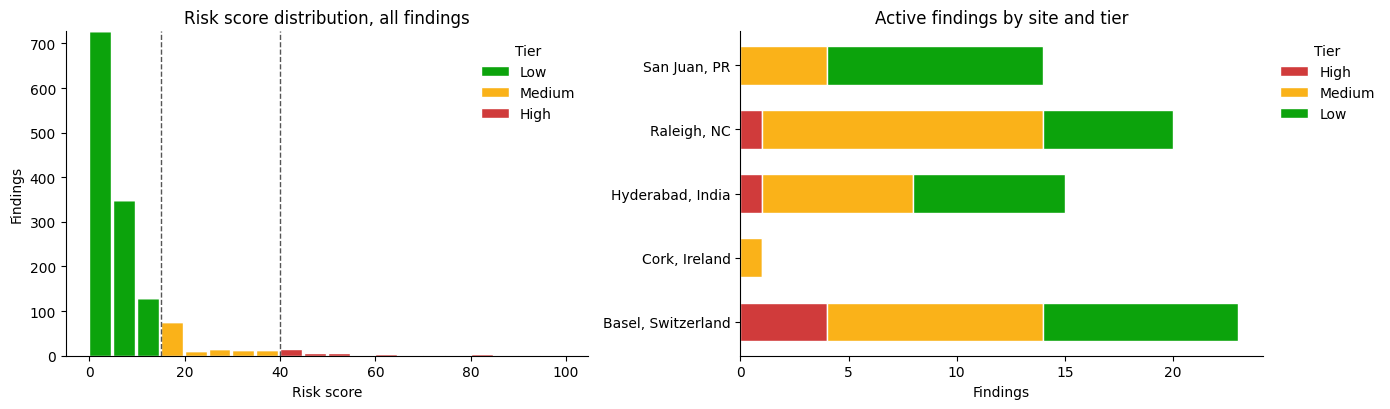

In [6]:
TIER_COLORS = {'High': '#d03b3b', 'Medium': '#fab219', 'Low': '#0ca30c'}

print('All findings by tier:')
print(scored['risk_tier'].value_counts().reindex(TIERS).to_string())
print('\nActive findings (CAPA not closed) by tier:')
print(scored.loc[active, 'risk_tier'].value_counts().reindex(TIERS, fill_value=0).to_string())
print('\nFindings by CAPA status and tier:')
status_detail = pd.Series(np.where(scored['status'] == 'Closed', 'Closed - ' + scored['effectiveness_check'],
                                   scored['status']), index=scored.index, name='CAPA status')
print(pd.crosstab(status_detail, scored['risk_tier'])[TIERS].to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
bins = np.arange(0, 101, 5)
bottom = np.zeros(len(bins) - 1)
for t in ['Low', 'Medium', 'High']:
    h, _ = np.histogram(scored.loc[scored['risk_tier'] == t, 'risk_score'], bins=bins)
    axes[0].bar(bins[:-1], h, width=4.6, align='edge', bottom=bottom, color=TIER_COLORS[t], label=t, edgecolor='white', linewidth=1)
    bottom += h
for c in WEIGHTS['tier_cutoffs'].values():
    axes[0].axvline(c, color='#555', lw=1, ls='--')
axes[0].set_title('Risk score distribution, all findings'); axes[0].set_xlabel('Risk score'); axes[0].set_ylabel('Findings')
axes[0].legend(title='Tier', frameon=False)

open_by_site = pd.crosstab(scored.loc[active, 'site_name'], scored.loc[active, 'risk_tier']).reindex(columns=TIERS, fill_value=0)
left = np.zeros(len(open_by_site))
for t in TIERS:
    axes[1].barh(open_by_site.index, open_by_site[t], left=left, color=TIER_COLORS[t], label=t, height=0.6, edgecolor='white', linewidth=1)
    left += open_by_site[t].to_numpy()
axes[1].set_title('Active findings by site and tier'); axes[1].set_xlabel('Findings')
axes[1].legend(title='Tier', frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1))
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Sensitivity check
How much do the results depend on the exact weights? Each test changes **one** weight and measures:
- **Tier changes:** share of findings that move to a different tier
- **Top-20 overlap:** how many of the 20 highest-risk active findings stay in the top 20

If small, reasonable changes keep the top 20 mostly the same, the ranking is **robust** and leadership
can trust it. Put the results table in your README.

In [7]:
import copy

def variant(change):
    W = copy.deepcopy(WEIGHTS); change(W); return W

tests = {
    'Major worth 6 instead of 5':          variant(lambda W: W['severity_points'].update(Major=6)),
    'Minor worth 1 instead of 2':          variant(lambda W: W['severity_points'].update(Minor=1)),
    'Overdue adds 2 instead of 3':         variant(lambda W: W.update(overdue_points=2)),
    'Recurrence capped at +2 instead of +3': variant(lambda W: W.update(recurrence_points_max=2)),
    'No sterile boost':                    variant(lambda W: W.update(sterile_boost=1.0)),
    'All process areas weighted equally':  variant(lambda W: W.update(area_criticality={k: 1.0 for k in W['area_criticality']})),
    'Failed CAPA counts like In Progress (5) → 4': variant(lambda W: W['status_points'].update({'Closed - Fail': 4})),
}

def top_ids(s, n=20):
    a = s[s['status'] != 'Closed']
    return set(a.sort_values(['risk_score', 'finding_id'], ascending=[False, True]).head(n)['finding_id'])

base_top = top_ids(scored)
rows = []
for name, W in tests.items():
    alt = score_findings(df, W)
    rows.append({'Change': name,
                 'Tier changes': f"{(alt['risk_tier'] != scored['risk_tier']).mean():.1%}",
                 'Top-20 overlap': f"{len(base_top & top_ids(alt))} / 20",
                 'High-tier count': f"{(scored['risk_tier'] == 'High').sum()} → {(alt['risk_tier'] == 'High').sum()}"})
sensitivity = pd.DataFrame(rows)
sensitivity

,Change,Tier changes,Top-20 overlap,High-tier count
0,Major worth 6 instead of 5,1.0%,20 / 20,33 → 46
1,Minor worth 1 instead of 2,5.7%,20 / 20,33 → 33
2,Overdue adds 2 instead of 3,0.0%,20 / 20,33 → 33
3,Recurrence capped at +2 instead of +3,4.4%,20 / 20,33 → 19
4,No sterile boost,0.6%,16 / 20,33 → 31
5,All process areas weighted equally,0.4%,20 / 20,33 → 35
6,Failed CAPA counts like In Progress (5) → 4,3.8%,20 / 20,33 → 18


## 8. Save the outputs
- `data/processed/findings_scored.csv`: one row per finding, every column the dashboard needs
- `models/risk_weights.json`: the exact weights used, so the Streamlit app (Phase 7) scores the same way

In [8]:
COLUMNS = [
    # identifiers and context
    'finding_id', 'audit_id', 'capa_id', 'site_id', 'site_name', 'product_type', 'region',
    'audit_date', 'audit_type', 'auditor_org',
    # the finding
    'process_area', 'category', 'cfr_reference', 'affected_item', 'severity', 'description',
    'prior_occurrence_count', 'is_recurrent',
    # the CAPA
    'open_date', 'due_date', 'close_date', 'status', 'effectiveness_check',
    'is_overdue', 'closed_late', 'days_open',
    # the score and its building blocks
    'severity_points', 'area_factor', 'impact', 'status_points', 'overdue_points', 'recurrence_points',
    'exposure', 'risk_score', 'risk_tier',
]
out_path = f'{PROCESSED_DIR}/findings_scored.csv'
scored[COLUMNS].to_csv(out_path, index=False, date_format='%Y-%m-%d')
print(f'Saved {len(scored)} rows, {len(COLUMNS)} columns → {out_path}')

with open(f'{MODELS_DIR}/risk_weights.json', 'w') as f:
    json.dump(WEIGHTS, f, indent=2)
print(f'Saved weights → {MODELS_DIR}/risk_weights.json')

Saved 1365 rows, 35 columns → /content/drive/MyDrive/gmp-audit-risk-dashboard/data/processed/findings_scored.csv
Saved weights → /content/drive/MyDrive/gmp-audit-risk-dashboard/models/risk_weights.json


## 9. Numbers for your documentation
Copy these into the data dictionary (risk_score and risk_tier rows) and the README.

In [9]:
print(f"Tier cut-offs: High ≥ {WEIGHTS['tier_cutoffs']['High']}, "
      f"Medium {WEIGHTS['tier_cutoffs']['Medium']}–{WEIGHTS['tier_cutoffs']['High'] - 0.1}, "
      f"Low < {WEIGHTS['tier_cutoffs']['Medium']}")
for t in TIERS:
    n = (scored['risk_tier'] == t).sum()
    print(f'{t:6s}: {n:4d} findings ({n / len(scored):.0%}) | active: {((scored.risk_tier == t) & active).sum()}')
print(f"\nActive findings: {active.sum()} | High-risk active: {((scored.risk_tier == 'High') & active).sum()}")
print('\nHigh-risk active findings by site:')
print(scored[active & (scored.risk_tier == 'High')].groupby('site_name').size().sort_values(ascending=False).to_string())

Tier cut-offs: High ≥ 40, Medium 15–39.9, Low < 15
High  :   33 findings (2%) | active: 6
Medium:  127 findings (9%) | active: 35
Low   : 1205 findings (88%) | active: 32

Active findings: 73 | High-risk active: 6

High-risk active findings by site:
site_name
Basel, Switzerland    4
Hyderabad, India      1
Raleigh, NC           1


## Next steps
1. Open `data/processed/findings_scored.csv` in Drive and spot-check a few high and low scores.
2. Update the data dictionary and add decision **D8** (text provided separately).
3. **File → Save a copy in GitHub** → `notebooks/02_risk_scoring.ipynb`.
4. Move on to Phase 4 (`03_analysis`).